In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn import metrics

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler #Chuẩn hóa dữ liệu

Scaler	Khi nào dùng?
StandardScaler	Dữ liệu phân phối chuẩn, dùng cho KNN, SVM, Logistic, PCA
MinMaxScaler	Khi cần giữ dữ liệu trong [0,1], dùng cho NN, khoảng cách

Sự khác nahu giữa scaler và Encoder
Tiêu chí	    Scaler (StandardScaler, MinMaxScaler, …)	    Encoder (LabelEncoder, OneHotEncoder, …)
Dùng cho	    Dữ liệu số (numeric features)	                Dữ liệu phân loại (categorical features)
Chuyển đổi	    Thay đổi độ lớn (scale), giữ ý nghĩa	        Chuyển nhãn thành số
Ví dụ đầu vào	[150, 160, 170] (chiều cao)	                    ["cat", "dog", "fish"]
Ví dụ đầu ra	[-1.2, 0.0, 1.2] (sau StandardScaler)	        [0, 1, 2] (sau LabelEncoder)
Ứng dụng	    KNN, SVM, PCA, Neural Network,…	                Decision Tree, Logistic Regression, NLP,…

👉 Tóm lại:

Scaler = chuẩn hóa số liệu (dành cho dữ liệu dạng số).

Encoder = biến đổi nhãn (dành cho dữ liệu dạng phân loại).

LabelEncoder: chuyển "Cat", "Dog", "Fish" → 0, 1, 2 (thứ tự).

get_dummies (One-Hot Encoding): tạo nhiều cột (Cat, Dog, Fish), giá trị 0/1.

👉 LabelEncoder phù hợp cho target (y),
👉 get_dummies()/OneHotEncoder phù hợp cho features (X).

Trong thuật toán K-means clustering, chúng ta không biết nhãn (label) của từng điểm dữ liệu. Mục đích là làm thể nào để phân dữ liệu thành các cụm (cluster) khác nhau sao cho dữ liệu trong cùng một cụm có tính chất giống nhau.
Giả sử mỗi cluster có một điểm đại diện (center) màu vàng. Và những điểm xung quanh mỗi center thuộc vào cùng nhóm với center đó. Một cách đơn giản nhất, xét một điểm bất kỳ, ta xét xem điểm đó gần với center nào nhất thì nó thuộc về cùng nhóm với center đó.

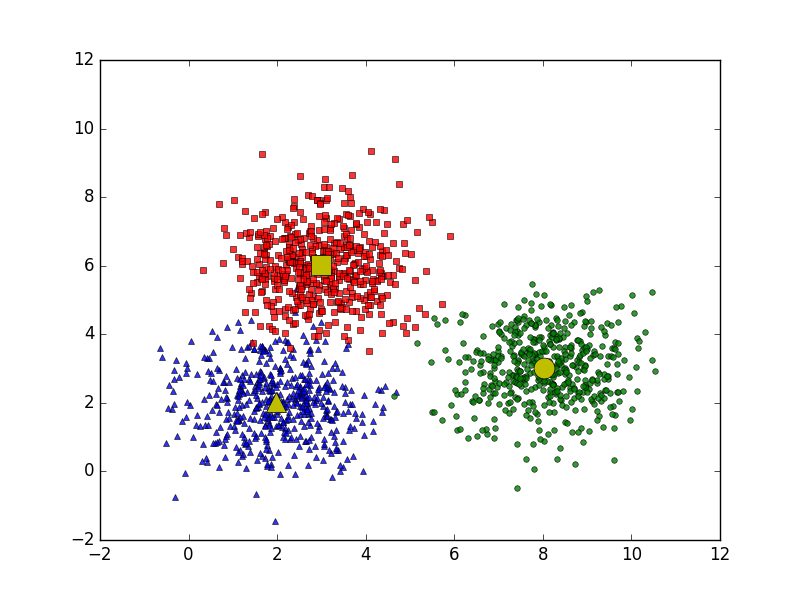

In [45]:
dt = pd.read_csv(r"C:\Users\ASUS\Downloads\income.csv")

In [46]:
dt.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


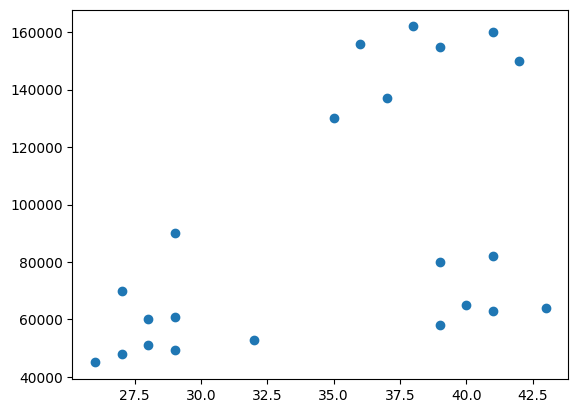

In [47]:
plt.scatter(dt['Age'],dt['Income($)'])

In [65]:
km = KMeans(n_clusters=3,init='k-means++', random_state=0)
y_predicted = km.fit_predict(dt[['Age','Income($)']])
y_predicted

array([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [66]:
dt['cluster']=y_predicted
dt.head()

,Name,Age,Income($),cluster,Cluster
0,Rob,27,0.213675,0,0
1,Michael,29,0.384615,0,0
2,Mohan,29,0.136752,0,0
3,Ismail,28,0.128205,0,0
4,Kory,42,0.897436,1,1


In [67]:
dt.drop(columns=['Cluster'])

,Name,Age,Income($),cluster
0,Rob,27,0.213675,0
1,Michael,29,0.384615,0
2,Mohan,29,0.136752,0
3,Ismail,28,0.128205,0
4,Kory,42,0.897436,1
5,Gautam,39,0.940171,1
6,David,41,0.982906,1
7,Andrea,38,1.000000,1
8,Brad,36,0.948718,2
9,Angelina,35,0.726496,2


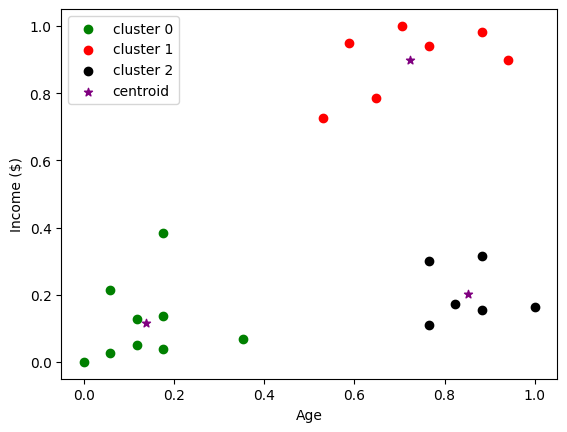

In [77]:
df1 = dt[dt.cluster==0]
df2 = dt[dt.cluster==1]
df3 = dt[dt.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green',label='cluster 0')
plt.scatter(df2.Age,df2['Income($)'],color='red',label='cluster 1')
plt.scatter(df3.Age,df3['Income($)'],color='black',label='cluster 2')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend()

Kết quả

kmeans.cluster_centers_: tọa độ tâm cụm.

kmeans.labels_: mỗi điểm dữ liệu thuộc cụm nào.

kmeans.inertia_: tổng bình phương khoảng cách đến cụm gần nhất (dùng để đánh giá chất lượng cụm).

AttributeError: type object 'KMeans' has no attribute 'inertia_'

In [ ]:
scaler = MinMaxScaler()


In [69]:
dt['Income($)'] = scaler.fit_transform(dt[['Income($)']])


In [70]:
dt['Age'] = scaler.fit_transform(dt[['Age']])


In [ ]:
dt.head()


,Name,Age,Income($),cluster
0,Rob,27,0.213675,2
1,Michael,29,0.384615,2
2,Mohan,29,0.136752,0
3,Ismail,28,0.128205,0
4,Kory,42,0.897436,1


In [71]:
km = KMeans(n_clusters=3, random_state=0)
y_predicted = km.fit_predict(dt[['Age','Income($)']])   
y_predicted

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [72]:
dt['cluster'] = y_predicted

In [73]:
dt.head()

,Name,Age,Income($),cluster,Cluster
0,Rob,0.058824,0.213675,0,0
1,Michael,0.176471,0.384615,0,0
2,Mohan,0.176471,0.136752,0,0
3,Ismail,0.117647,0.128205,0,0
4,Kory,0.941176,0.897436,1,1


In [74]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

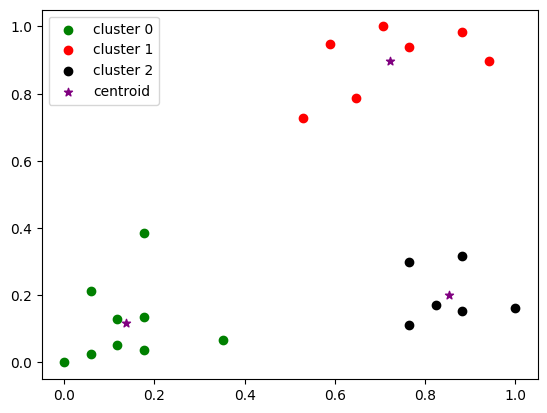

In [76]:
df1 = dt[dt.cluster==0]
df2 = dt[dt.cluster==1]
df3 = dt[dt.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green',label='cluster 0')
plt.scatter(df2.Age,df2['Income($)'],color='red',label='cluster 1')
plt.scatter(df3.Age,df3['Income($)'],color='black',label='cluster 2')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

Tìm n_cluster tối ưu nhất
Elbow Method: Nhìn sơ bộ 

In [80]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(dt[['Age','Income($)']])
    sse.append(km.inertia_)

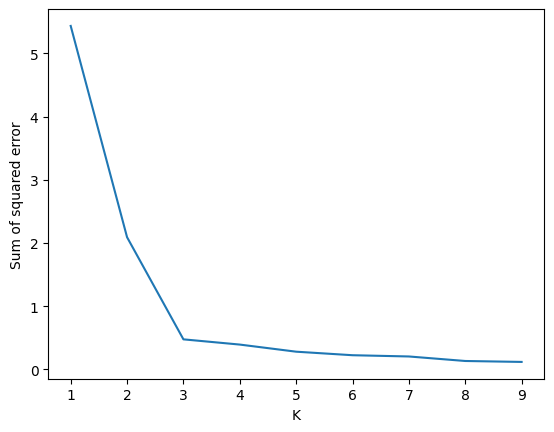

In [81]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

 Ý nghĩa
SSE càng nhỏ → dữ liệu nằm gần tâm cụm → phân cụm "chặt chẽ".
SSE càng lớn → dữ liệu nằm xa tâm cụm → phân cụm lỏng lẻo.

Lưu ý
Khi tăng số cụm 𝑘
k, SSE luôn giảm (vì mỗi cụm có ít điểm hơn, dễ “ôm sát” dữ liệu hơn).
Nhưng nếu 𝑘=𝑛
k=n (mỗi điểm là 1 cụm) → SSE = 0 → vô nghĩa.
Vì thế ta dùng Elbow Method: tìm điểm mà SSE giảm chậm lại (điểm khuỷu tay) để chọn số cụm tối ưu.

Silhouette Score để xác nhận và chọn số cụm tối ưu.

In [82]:
from sklearn.metrics import silhouette_score

In [83]:
score=[]
K = range(2,10)
for k in K:
    km= KMeans(n_clusters=k)
    km.fit(dt[['Age','Income($)']])
    sc = silhouette_score(dt[['Age','Income($)']],km.labels_)
    score.append(sc)

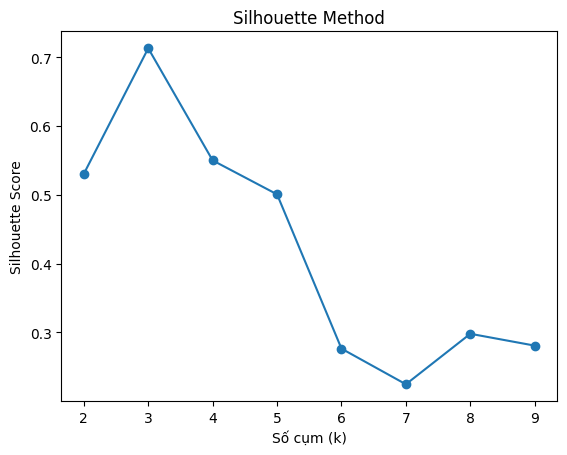

In [84]:

plt.plot(K, score, marker='o')
plt.xlabel("Số cụm (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

Silhouette score ∈ [-1,1]:

Gần 1 → các cụm rõ ràng, tách biệt tốt.

Gần 0 → các cụm chồng lấn.

Âm (<0) → phân cụm tệ (dữ liệu bị đặt nhầm cụm).

Chọn k có silhouette score cao nhất.